#Stacking Ensemble Method
https://dev.to/sreeni5018/understanding-stacking-ensemble-method-a-comprehensive-guide-part-iv-1c29

Imports

In [1]:
import numpy as np

#Dataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

#Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

#Ensemble
from sklearn.ensemble import StackingClassifier

#Validation
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

Load dataset

In [2]:
# Load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Base classifiers

In [3]:
base_classifiers = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('svc', SVC(probability=True, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=3)),
    ('nb', GaussianNB())
    ]

Se define un conjunto de clasificadores base, en este caso 5.

Stacking

In [4]:
def evaluate_meta_classifiers(base_classifiers, meta_classifiers, X_train, X_test, y_train, y_test):
  results = {}
  for name, meta_clf in meta_classifiers.items():
    stacking = StackingClassifier(
        estimators=base_classifiers,
        final_estimator=meta_clf,
        cv=5,
        stack_method='predict_proba'
        )
    stacking.fit(X_train, y_train)
    y_pred = stacking.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {'accuracy': accuracy, 'y_pred': y_pred}
  return results

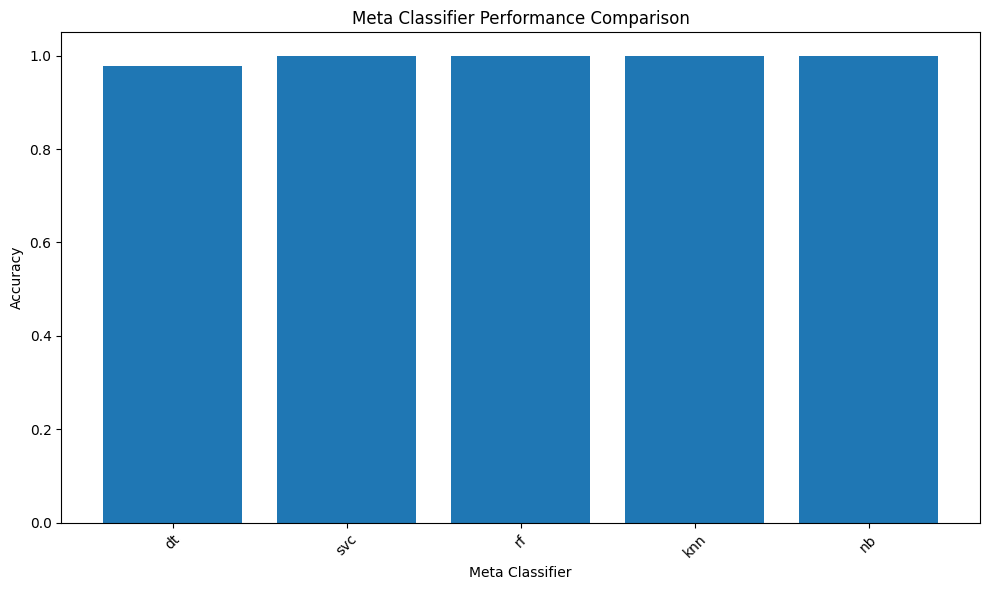

In [5]:
meta_classifiers = {
    'dt': DecisionTreeClassifier(random_state=42),
    'svc': SVC(probability=True, random_state=42),
    'rf': RandomForestClassifier(random_state=42),
    'knn': KNeighborsClassifier(),
    'nb': GaussianNB()
}

meta_results = evaluate_meta_classifiers(base_classifiers, meta_classifiers, X_train, X_test, y_train, y_test)

plt.figure(figsize=(10, 6))
plt.bar(meta_results.keys(), [res['accuracy'] for res in meta_results.values()])
plt.title('Meta Classifier Performance Comparison')
plt.xlabel('Meta Classifier')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se entrena un "Meta clasificador" que lo que hace es aprender sobre las predicciones individuales de los modelos, es como un nivel jerárquico mayor.


--- Results for Meta-Classifier: dt ---
Accuracy: 0.9778
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



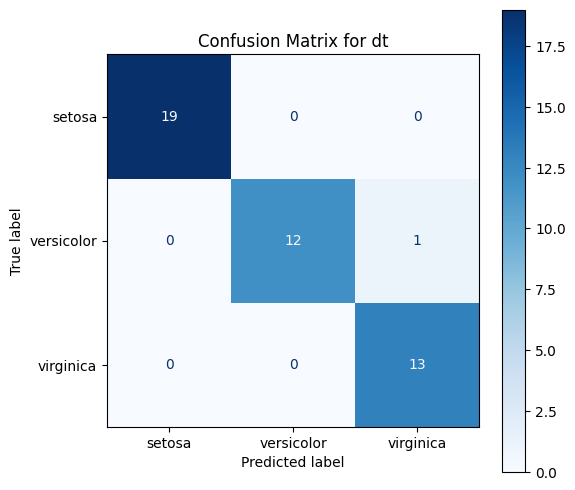


--- Results for Meta-Classifier: svc ---
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



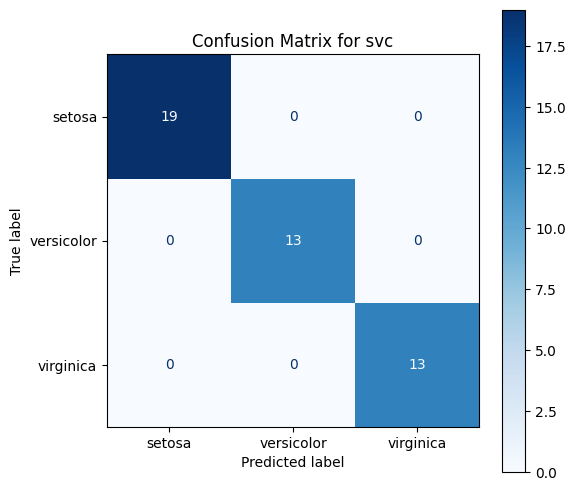


--- Results for Meta-Classifier: rf ---
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



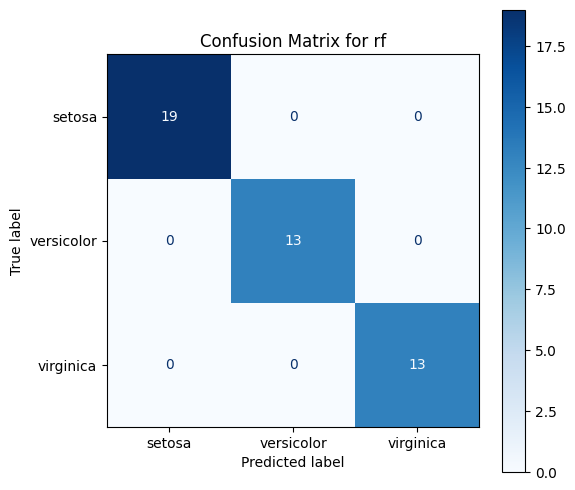


--- Results for Meta-Classifier: knn ---
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



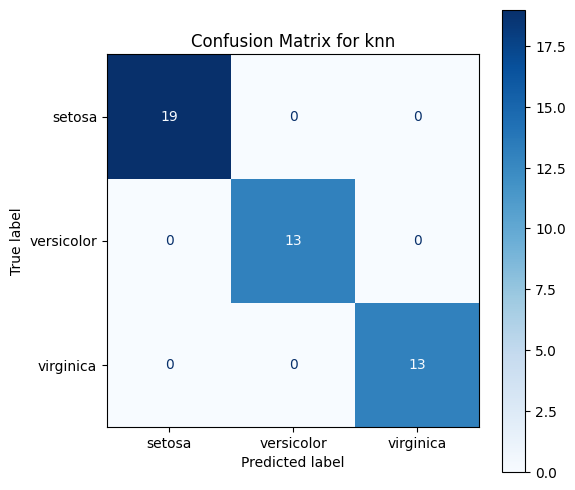


--- Results for Meta-Classifier: nb ---
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



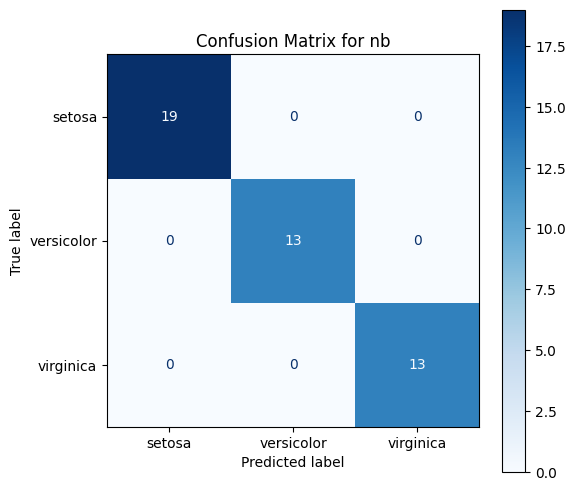

In [6]:
if 'iris' not in locals():
    from sklearn.datasets import load_iris
    iris = load_iris()

for name, result in meta_results.items():
    y_pred = result['y_pred']
    accuracy = result['accuracy']
    print(f"\n--- Results for Meta-Classifier: {name} ---")
    print(f"Accuracy: {accuracy:.4f}")

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(f'Confusion Matrix for {name}')
    plt.show()

¡Se logran predicciones perfectas en el conjunto de datos IRIS!